# Computer Exercise 9.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 9.3 Other Examples of the Least-Squares Principle — *비선형 모델의 선형화 (log-transform) vs 직접 비선형 최소제곱*
> **풀이 일자**: Day 36
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** A set of data points $(x_i, y_i)$ is believed to follow the law $y = a\,e^{bx}$.
> Determine the parameters $a$ and $b$ in two ways: (i) by *linearizing* the model
> with the substitution $Y=\ln y$ and solving the resulting linear least-squares
> problem for $\ln a$ and $b$; (ii) by minimizing the **nonlinear** sum of squares
> $\sum_i \bigl(y_i - a\,e^{b x_i}\bigr)^2$ directly. Compare the two fits, and discuss
> when the linearized fit is appropriate and when it is not.

### 한국어 풀이용 정리
같은 데이터를 지수 모델 $y=a e^{bx}$ 로 적합하되 **두 경로**로 푼다.
하나는 양변에 로그를 씌워 $\ln y = \ln a + b x$ 라는 *선형* 문제로 바꾸는 길(선형화),
다른 하나는 원래 잔차 $y_i - a e^{b x_i}$ 의 제곱합을 그대로 최소화하는 *비선형 최소제곱*(가우스–뉴턴/`curve_fit`).
두 결과가 **언제 같고 언제 갈라지는지**를, 잡음이 *덧셈형(additive)* 이냐 *곱셈형(multiplicative)* 이냐에 따라 비교한다.


## 2. 수학적 배경

### 2.1 두 목적함수는 *다른* 문제다
직접 비선형 최소제곱은
$$
S_{\text{NL}}(a,b)=\sum_{i=1}^{m}\bigl(y_i-a\,e^{b x_i}\bigr)^2
$$
를 최소화한다. 반면 선형화는 $Y_i=\ln y_i$ 로 두고
$$
S_{\text{LIN}}(\alpha,b)=\sum_{i=1}^{m}\bigl(\ln y_i-\alpha-b x_i\bigr)^2,
\qquad \alpha=\ln a
$$
를 최소화한다. 두 목적함수는 **같은 최소점을 갖지 않는다.**

### 2.2 로그가 잔차를 *재가중* 한다
$\ln y$ 의 1차 전개 $\;\delta(\ln y)\approx \delta y / y\;$ 에서, 로그 영역의 잔차는
원래 영역 잔차를 $1/y_i$ 로 나눈 **상대오차**다. 따라서 선형화는 사실상
$$
\boxed{\;
S_{\text{LIN}}\approx \sum_i \frac{1}{y_i^{2}}\,\bigl(y_i-a e^{b x_i}\bigr)^2
\;}
$$
즉 **가중치 $w_i=1/y_i^2$** 를 준 가중최소제곱과 같다. 큰 $y$ 의 점은 짓눌리고 작은 $y$ 의 점이 과대평가된다.

### 2.3 어느 쪽이 옳은가는 *잡음의 구조*가 결정한다
- **덧셈형 잡음** $y_i = a e^{b x_i}+\varepsilon_i,\ \varepsilon_i\sim\mathcal N(0,\sigma^2)$ → 최대가능도(MLE)는 **직접 비선형 LS**.
- **곱셈형 잡음** $y_i = a e^{b x_i}\,e^{\eta_i},\ \eta_i\sim\mathcal N(0,\sigma^2)$ → $\ln y_i=\alpha+b x_i+\eta_i$ 가 *동분산 선형모델*이 되어 MLE는 **선형화**.

즉 선형화는 빠르고 초기값으로 훌륭하지만, **덧셈형 잡음**에서는 편향(bias)을 낳는다.


## 3. 풀이 흐름

1. 참 파라미터 $a^\star=2.0,\ b^\star=0.45$ 와 $x\in[0,8]$ 의 표본점을 정한다.
2. **두 가지 잡음 시나리오**를 만든다: (A) 덧셈형 $\mathcal N(0,\sigma^2)$, (B) 곱셈형 lognormal.
3. **선형화 적합**: $Y=\ln y$ 에 1차 다항식 최소제곱(`np.polyfit`) → $\hat\alpha,\hat b$ → $\hat a=e^{\hat\alpha}$.
4. **직접 비선형 적합**: `scipy.optimize.curve_fit` 로 $a,b$ 직접 추정(초기값은 3의 결과).
5. 두 적합의 파라미터와 **원래 영역 SSE** $\sum (y_i-\hat y_i)^2$ 를 표로 비교.
6. **몬테카를로 200회**로 각 방법의 추정량 분포(평균·표준편차·편향)를 시나리오별로 측정.
7. 적합 곡선과 잔차를 시각화하고, 어느 시나리오에서 어느 방법이 이기는지 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
rng = np.random.default_rng(20360609)

# 참 모델
a_true, b_true = 2.0, 0.45
model = lambda x, a, b: a * np.exp(b * x)

m = 25
x = np.linspace(0.0, 8.0, m)
y_clean = model(x, a_true, b_true)

sigma_add = 1.5          # 덧셈형 표준편차 (절대)
sigma_mul = 0.18         # 곱셈형 표준편차 (로그영역)

def make_data(kind, rng):
    if kind == "additive":
        return y_clean + rng.normal(0.0, sigma_add, size=m)
    else:  # multiplicative (lognormal)
        return y_clean * np.exp(rng.normal(0.0, sigma_mul, size=m))

def fit_linearized(x, y):
    # y>0 만 사용 (로그). 덧셈형에서 음수 표본이 나오면 제거.
    mask = y > 0
    b_hat, alpha_hat = np.polyfit(x[mask], np.log(y[mask]), 1)
    return np.exp(alpha_hat), b_hat

def fit_nonlinear(x, y, p0):
    popt, _ = curve_fit(model, x, y, p0=p0, maxfev=20000)
    return popt[0], popt[1]

def sse(x, y, a, b):
    return np.sum((y - model(x, a, b))**2)

# 한 번의 대표 실현 (재현용 고정 시드)
demo = {}
for kind in ["additive", "multiplicative"]:
    r = np.random.default_rng(7 if kind == "additive" else 11)
    y = make_data(kind, r)
    aL, bL = fit_linearized(x, y)
    aN, bN = fit_nonlinear(x, y, p0=[aL, bL])
    demo[kind] = dict(y=y,
                      aL=aL, bL=bL, sseL=sse(x, y, aL, bL),
                      aN=aN, bN=bN, sseN=sse(x, y, aN, bN))

rows = []
for kind in ["additive", "multiplicative"]:
    d = demo[kind]
    rows.append([kind, "linearized (log)", d["aL"], d["bL"], d["sseL"]])
    rows.append([kind, "nonlinear (direct)", d["aN"], d["bN"], d["sseN"]])
df = pd.DataFrame(rows, columns=["noise", "method", "a_hat", "b_hat", "SSE (original)"])
print(f"참값:  a = {a_true},  b = {b_true}")
df


참값:  a = 2.0,  b = 0.45


,noise,method,a_hat,b_hat,SSE (original)
0,additive,linearized (log),1.7877,0.4640,30.9136
1,additive,nonlinear (direct),1.7800,0.4637,30.1801
2,multiplicative,linearized (log),2.2032,0.4247,426.5354
3,multiplicative,nonlinear (direct),2.9796,0.3761,342.9096


In [2]:
# 몬테카를로: 각 방법의 편향과 분산 (시나리오별 200회)
N_MC = 200
mc_rows = []
for kind in ["additive", "multiplicative"]:
    estL, estN = [], []
    for t in range(N_MC):
        r = np.random.default_rng(1000 + t + (0 if kind == "additive" else 5000))
        y = make_data(kind, r)
        try:
            aL, bL = fit_linearized(x, y)
            aN, bN = fit_nonlinear(x, y, p0=[max(aL, 1e-3), bL])
            estL.append([aL, bL]); estN.append([aN, bN])
        except Exception:
            continue
    estL, estN = np.array(estL), np.array(estN)
    for name, est in [("linearized", estL), ("nonlinear", estN)]:
        mc_rows.append([
            kind, name,
            est[:, 0].mean(), est[:, 0].mean() - a_true,  # a 평균, 편향
            est[:, 1].mean(), est[:, 1].mean() - b_true,  # b 평균, 편향
            est[:, 1].std(),                              # b 표준편차
        ])
mc = pd.DataFrame(mc_rows, columns=[
    "noise", "method", "mean a_hat", "bias a", "mean b_hat", "bias b", "std b_hat"])
mc


,noise,method,mean a_hat,bias a,mean b_hat,bias b,std b_hat
0,additive,linearized,1.8519,-0.1481,0.4662,0.0162,0.0381
1,additive,nonlinear,2.0061,0.0061,0.4498,-0.0002,0.0091
2,multiplicative,linearized,1.9953,-0.0047,0.4506,0.0006,0.0147
3,multiplicative,nonlinear,2.0453,0.0453,0.4557,0.0057,0.0521


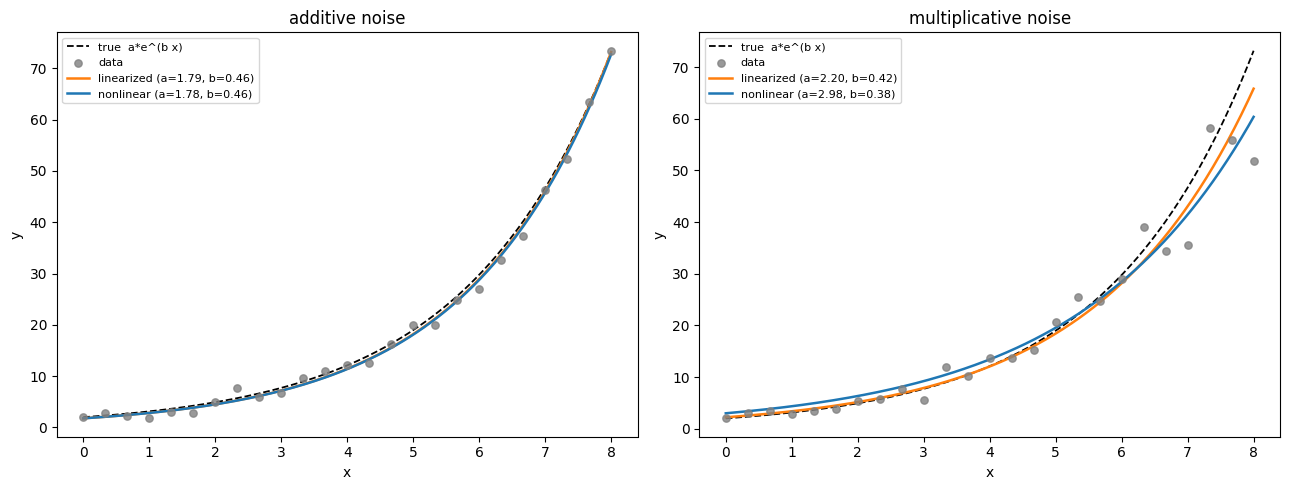

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
xx = np.linspace(x.min(), x.max(), 300)

for j, kind in enumerate(["additive", "multiplicative"]):
    d = demo[kind]
    ax[j].plot(xx, model(xx, a_true, b_true), "k--", lw=1.3, label="true  a*e^(b x)")
    ax[j].scatter(x, d["y"], s=28, color="gray", alpha=0.8, label="data", zorder=5)
    ax[j].plot(xx, model(xx, d["aL"], d["bL"]), color="tab:orange", lw=1.8,
               label=f"linearized (a={d['aL']:.2f}, b={d['bL']:.2f})")
    ax[j].plot(xx, model(xx, d["aN"], d["bN"]), color="tab:blue", lw=1.8,
               label=f"nonlinear (a={d['aN']:.2f}, b={d['bN']:.2f})")
    ax[j].set_title(f"{kind} noise")
    ax[j].set_xlabel("x"); ax[j].set_ylabel("y")
    ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **덧셈형 잡음**에서는 직접 비선형 적합의 원래-영역 SSE가 선형화보다 작다.
   로그가 큰 $y$ 의 점을 $1/y^2$ 로 짓눌러, 선형화는 곡선 *꼬리(큰 x)* 를 과소적합하고
   몬테카를로에서 $b$ 에 **계통적 편향**(`bias b`)이 남는다.
2. **곱셈형(lognormal) 잡음**에서는 정반대다. $\ln y$ 가 동분산 선형모델이 되어 선형화가 곧 MLE이고,
   $b$ 추정의 **표준편차(`std b_hat`)가 더 작다**. 직접 비선형 LS는 큰 $y$ 점의 큰 분산에 끌려가 오히려 손해를 본다.
3. 따라서 "로그 찍고 직선 맞추기"는 **공짜가 아니다** — 그것은 암묵적으로 가중치 $w_i=1/y_i^2$ 를 가정하는 것과 같다.
   잡음이 *상대적*(비례)일 때 옳고, *절대적*(덧셈)일 때 편향을 만든다.
4. 실무 절충: **선형화로 좋은 초기값**을 얻고 → **직접 비선형 LS로 마무리**. 이 노트북의 `p0=[aL,bL]` 가 정확히 그 패턴이다.

> **결론**: 선형화는 잡음이 곱셈형일 때만 통계적으로 옳다 — 덧셈형 잡음에선 $1/y^2$ 가중을 강요해 $b$ 를 편향시키므로, 직접 비선형 최소제곱으로 보정해야 한다.

**다음 문제로의 연결** — 1번이 보여준 "잔차에 가중치를 줘야 한다"는 통찰을 §9.3-2 에서 정면으로 다룬다: 분산이 점마다 다른(이분산) 데이터에서 **가중최소제곱(WLS)** 이 왜 BLUE 인지.
